Implementation of character level language model.It predicts the next character in the sequence based on 3 input characters.

The model is implemented using a Multi-Layer Perceptron (MLP), which consists of one or more hidden layers with non-linear activations, followed by an output layer that produces a probability distribution over all possible next characters using softmax.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('/kaggle/input/datasets/maitrivaghela/namesdata/names_makemore.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [4]:
# ------------------build the dataset with training, dev and test split data -------------

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
# Will get same random numbers everytime since 
# starting point for the random number generation is already defined
random.seed(42)
# shuffling output will always be the same since the seed is initialized above
random.shuffle(words)
# 80% point of the list
n1 = int(0.8 * len(words))
# 90% point of the list
n2 = int(0.9 * len(words))

# build training dataset
Xtr, Ytr = build_dataset(words[:n1])
# build dev dataset -> dev dataset is build for hyper params of NN
Xdev, Ydev = build_dataset(words[n1:n2])
# build data set for validationr result of the model
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
lossi = []
stepi = []

In [6]:
# -------------------NN with dats split-------------------

# Initializing weights and bias
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

# number of parameters in total
sum(p.nelement() for p in parameters) 

for p in parameters:
    p.requires_grad = True

# update
for i in range(200000):
    # minibatch construct
    # it will give 32 random numbers from 0 to number of rows in Xtr
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] #(32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # Change learning rate after few iterations
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())
    

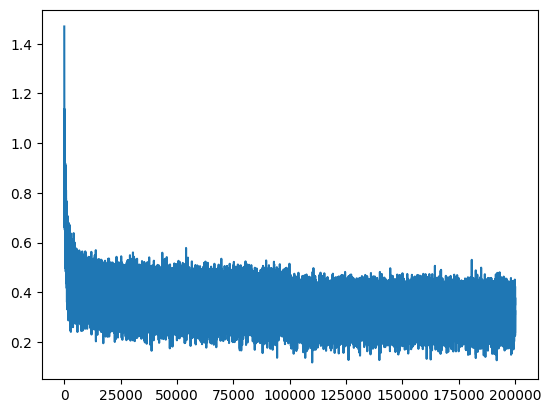

In [7]:
plt.plot(stepi, lossi)

In [8]:
# ------------- NN - dev data training set-----------------------

# The model is not trained on dev data set. 
# We are using this data set to compare the loss between training data set and dev data set
# to avoid overfitting of the model.
# When training loss and dev loss are amlost equal, we are underfitting the model
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss


tensor(2.1647, grad_fn=<NllLossBackward0>)

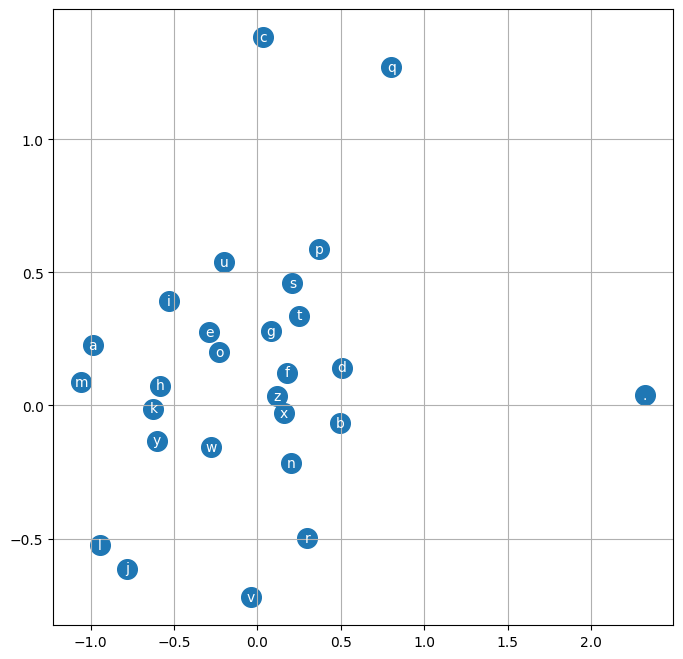

In [9]:
# Visualize the output of model
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [10]:
# sampling from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    # initializing the context array with dots
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])] 
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carman.
ambrilli.
kimis.
rehtykenley.
kenrahnevalee.
rhc.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
join.
quinn.
shon.
wai.
adbi.
wazerridiarynix.
kaeliigs.
bres.
edi.
